In [189]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data Cleaning

## Basic Data Exploratory

Element is id of player throughout the season, some names are duplicates but not same person
a triple gameweek was played in 21
there is a player that played that have same name but in different teams, this explains the person that played 4 matches in 1 gw

In [190]:
master = pd.read_csv('master_team_list.csv')

In [191]:
master.head()

,season,team,team_name
0,2016-17,1,Arsenal
1,2016-17,2,Bournemouth
2,2016-17,3,Burnley
3,2016-17,4,Chelsea
4,2016-17,5,Crystal Palace


In [192]:
master.count()

season       140
team         140
team_name    140
dtype: int64

In [193]:
fpl = pd.read_csv('cleaned_merged_seasons.csv')

C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_34132\2590381611.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  fpl = pd.read_csv('cleaned_merged_seasons.csv')


In [194]:
fpl.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,True,0,1
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,NaN,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,False,0,1
4,2016-17,Adam Forshaw,MID,NaN,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,True,1,1


In [195]:
pd.set_option('display.max_columns', None)

In [196]:
fpl.tail()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
96164,2022-23,Oliver Skipp,MID,Spurs,0,0,16,0,0.0,441,377,1,0,0.0,0.0,2023-05-28T15:30:00Z,90,11,Leeds,0,0,0,0,38,0,16761,4.0,1.0,0.0,2,100,742,642,43,False,0,38
96165,2022-23,Ryan Sessegnon,DEF,Spurs,0,0,0,0,0.0,436,377,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,11,Leeds,0,0,0,0,38,0,58774,4.0,1.0,0.0,0,-166,24,190,44,False,0,38
96166,2022-23,Ashley Young,DEF,Aston Villa,0,0,0,0,0.0,538,372,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,5,Brighton,0,0,0,0,38,0,96712,1.0,2.0,0.0,0,-1146,1522,2668,43,True,0,38
96167,2022-23,Jeremy Sarmiento Morante,MID,Brighton,0,0,0,0,0.0,119,372,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,2,Aston Villa,0,0,0,0,38,0,4511,1.0,2.0,0.0,0,-17,22,39,45,False,0,38
96168,2022-23,Philip Billing,MID,Bournemouth,0,0,15,0,0.0,70,376,1,0,0.0,0.0,2023-05-28T15:30:00Z,90,8,Everton,0,0,0,0,38,0,98162,0.0,1.0,0.0,2,-18361,736,19097,50,False,0,38


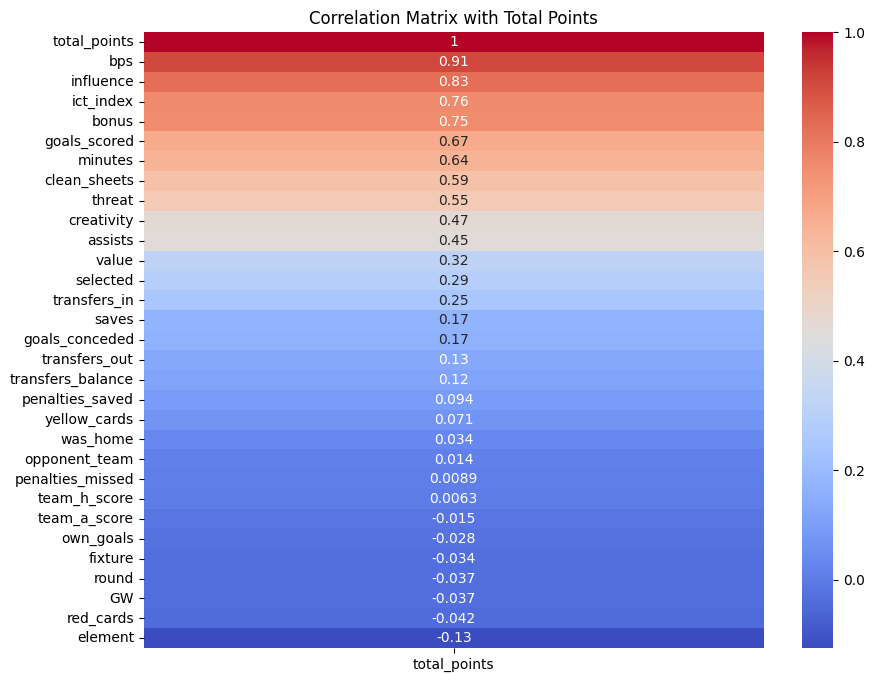

In [197]:
corr = fpl.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr[['total_points']].sort_values(by='total_points', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix with Total Points')
plt.show()

In [198]:
fpl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96169 entries, 0 to 96168
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   season_x           96169 non-null  object 
 1   name               96169 non-null  object 
 2   position           96169 non-null  object 
 3   team_x             76317 non-null  object 
 4   assists            96169 non-null  int64  
 5   bonus              96169 non-null  int64  
 6   bps                96169 non-null  int64  
 7   clean_sheets       96169 non-null  int64  
 8   creativity         96169 non-null  float64
 9   element            96169 non-null  int64  
 10  fixture            96169 non-null  int64  
 11  goals_conceded     96169 non-null  int64  
 12  goals_scored       96169 non-null  int64  
 13  ict_index          96169 non-null  float64
 14  influence          96169 non-null  float64
 15  kickoff_time       96169 non-null  object 
 16  minutes            961

In [199]:
fpl.tail()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
96164,2022-23,Oliver Skipp,MID,Spurs,0,0,16,0,0.0,441,377,1,0,0.0,0.0,2023-05-28T15:30:00Z,90,11,Leeds,0,0,0,0,38,0,16761,4.0,1.0,0.0,2,100,742,642,43,False,0,38
96165,2022-23,Ryan Sessegnon,DEF,Spurs,0,0,0,0,0.0,436,377,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,11,Leeds,0,0,0,0,38,0,58774,4.0,1.0,0.0,0,-166,24,190,44,False,0,38
96166,2022-23,Ashley Young,DEF,Aston Villa,0,0,0,0,0.0,538,372,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,5,Brighton,0,0,0,0,38,0,96712,1.0,2.0,0.0,0,-1146,1522,2668,43,True,0,38
96167,2022-23,Jeremy Sarmiento Morante,MID,Brighton,0,0,0,0,0.0,119,372,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,2,Aston Villa,0,0,0,0,38,0,4511,1.0,2.0,0.0,0,-17,22,39,45,False,0,38
96168,2022-23,Philip Billing,MID,Bournemouth,0,0,15,0,0.0,70,376,1,0,0.0,0.0,2023-05-28T15:30:00Z,90,8,Everton,0,0,0,0,38,0,98162,0.0,1.0,0.0,2,-18361,736,19097,50,False,0,38


Notes:

There are 380 Fixtures in a premierleague season, that's why the max is 380

In [200]:
fpl.describe()

,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,GW
count,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,9.616900e+04,96169.000000,96169.000000,96169.000000,96169.000000,9.616900e+04,9.616900e+04,9.616900e+04,96169.000000,96169.000000,96169.000000
mean,0.041042,0.108715,6.080275,0.106739,4.734000,327.063264,198.413824,0.495887,0.045514,1.715793,7.146263,32.466117,10.505496,0.001633,0.001029,0.000717,0.001716,20.772099,0.101894,2.021442e+05,1.265158,1.516393,5.287598,1.379270,1.677100e+03,1.454716e+04,1.286945e+04,51.352390,0.053167,20.772099
std,0.215378,0.492334,9.850595,0.308783,10.689879,194.313766,108.884200,0.974269,0.233644,3.042551,12.873136,40.574888,5.764941,0.040629,0.032069,0.026776,0.041386,10.941742,0.650732,5.362493e+05,1.229086,1.349184,13.368420,2.542535,6.581628e+04,5.725343e+04,4.840128e+04,12.667432,0.224367,10.941742
min,0.000000,0.000000,-21.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-7.000000,-2.180978e+06,0.000000e+00,0.000000e+00,37.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,159.000000,105.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,5.457000e+03,0.000000,1.000000,0.000000,0.000000,-1.374000e+03,4.600000e+01,1.280000e+02,44.000000,0.000000,11.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,318.000000,203.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,22.000000,0.000000,2.763900e+04,1.000000,1.000000,0.000000,0.000000,-5.800000e+01,4.380000e+02,1.104000e+03,48.000000,0.000000,22.000000
75%,0.000000,0.000000,10.000000,0.000000,2.400000,486.000000,293.000000,1.000000,0.000000,2.500000,10.600000,90.000000,16.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,1.456790e+05,2.000000,2.000000,2.000000,2.000000,7.900000e+01,5.042000e+03,7.562000e+03,54.000000,0.000000,30.000000
max,4.000000,3.000000,128.000000,1.000000,170.900000,778.000000,380.000000,9.000000,4.000000,32.800000,163.600000,90.000000,20.000000,2.000000,1.000000,1.000000,1.000000,38.000000,14.000000,9.582624e+06,7.000000,9.000000,186.000000,29.000000,1.983733e+06,2.104464e+06,2.233619e+06,133.000000,1.000000,38.000000


In [201]:
fpl.describe(include=['object'])

,season_x,name,position,team_x,kickoff_time,opp_team_name
count,96169,96169,96169,76317,96169,96169
unique,5,1327,5,25,1220,31
top,2022-23,Ben Davies,MID,Everton,2023-05-28T15:30:00Z,Crystal Palace
freq,26505,283,39163,4079,778,4818


This is the data set that we are going to match id with element and then add the code which is the thing consistent throughout seasons, this data is acquired from the github repo of the kaggle dataset provider found at: https://github.com/vaastav/Fantasy-Premier-League/blob/master/data/

In [202]:
raw_16_17 = pd.read_csv('./supplementary_data_sets/players_raw_16_17.csv')
raw_17_18 = pd.read_csv('./supplementary_data_sets/players_raw_17_18.csv')
raw_20_21 = pd.read_csv('./supplementary_data_sets/players_raw_20_21.csv')
raw_21_22 = pd.read_csv('./supplementary_data_sets/players_raw_21_22.csv')
raw_22_23 = pd.read_csv('./supplementary_data_sets/players_raw_22_23.csv')


In [203]:
raw_16_17.head()

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,ea_index,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,id,in_dreamteam,influence,loaned_in,loaned_out,loans_in,loans_out,minutes,news,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards
0,0,0,18,100.0,100.0,0,48844,0,0,-3,3,0.0,0,56,1,0.0,0.0,0,David,0.0,4,0,2.9,1,False,28.8,0,0,0,0,143,NaN,47,0,0,0,48844.jpg,1.0,0,4,Ospina,0.2,False,13.0,a,1,3,0.0,2,3433,0,7905,0,0.0,0.4,Ospina,0
1,0,2,660,100.0,100.0,12,11334,0,0,-1,1,0.1,0,409,1,6.0,0.0,4,Petr,0.0,37,0,82.0,2,False,819.8,0,0,0,0,3097,NaN,54,1,0,0,11334.jpg,3.8,0,115,Cech,13.7,False,33.0,a,1,3,0.0,134,432837,0,590727,0,0.0,24.8,Cech,2
2,1,19,723,0.0,75.0,10,51507,0,0,1,-1,53.9,3,493,2,1.7,0.0,-2,Laurent,0.0,37,2,112.7,3,False,831.2,0,0,0,0,2821,Suspended - unknown return date,61,0,0,0,51507.jpg,3.7,1,0,Koscielny,11.2,False,6.0,s,1,3,239.0,121,965040,0,857277,0,0.0,19.8,Koscielny,4
3,0,0,5,100.0,100.0,0,17127,0,0,-2,2,0.1,0,265,2,0.0,0.0,1,Per,0.0,1,0,1.8,4,False,17.8,0,0,0,0,38,NaN,48,0,0,0,17127.jpg,1.0,0,0,Mertesacker,0.2,False,4.0,a,1,3,0.0,1,2141,0,5912,0,0.0,0.2,Mertesacker,0
4,0,2,296,75.0,100.0,5,158074,0,0,-2,2,84.5,0,244,2,1.0,0.0,0,Gabriel Armando,0.0,18,0,50.0,5,False,295.8,0,0,0,0,1517,Knee injury - 75% chance of playing,48,0,0,0,158074.jpg,2.4,0,0,de Abreu,0.8,False,5.0,d,1,3,119.0,45,119600,0,100361,0,0.0,9.4,Gabriel,6


## Handling Null Values

In [204]:
fpl.isnull().sum()

season_x                 0
name                     0
position                 0
team_x               19852
assists                  0
bonus                    0
bps                      0
clean_sheets             0
creativity               0
element                  0
fixture                  0
goals_conceded           0
goals_scored             0
ict_index                0
influence                0
kickoff_time             0
minutes                  0
opponent_team            0
opp_team_name            0
own_goals                0
penalties_missed         0
penalties_saved          0
red_cards                0
round                    0
saves                    0
selected                 0
team_a_score             0
team_h_score             0
threat                   0
total_points             0
transfers_balance        0
transfers_in             0
transfers_out            0
value                    0
was_home                 0
yellow_cards             0
GW                       0
d

<Axes: >

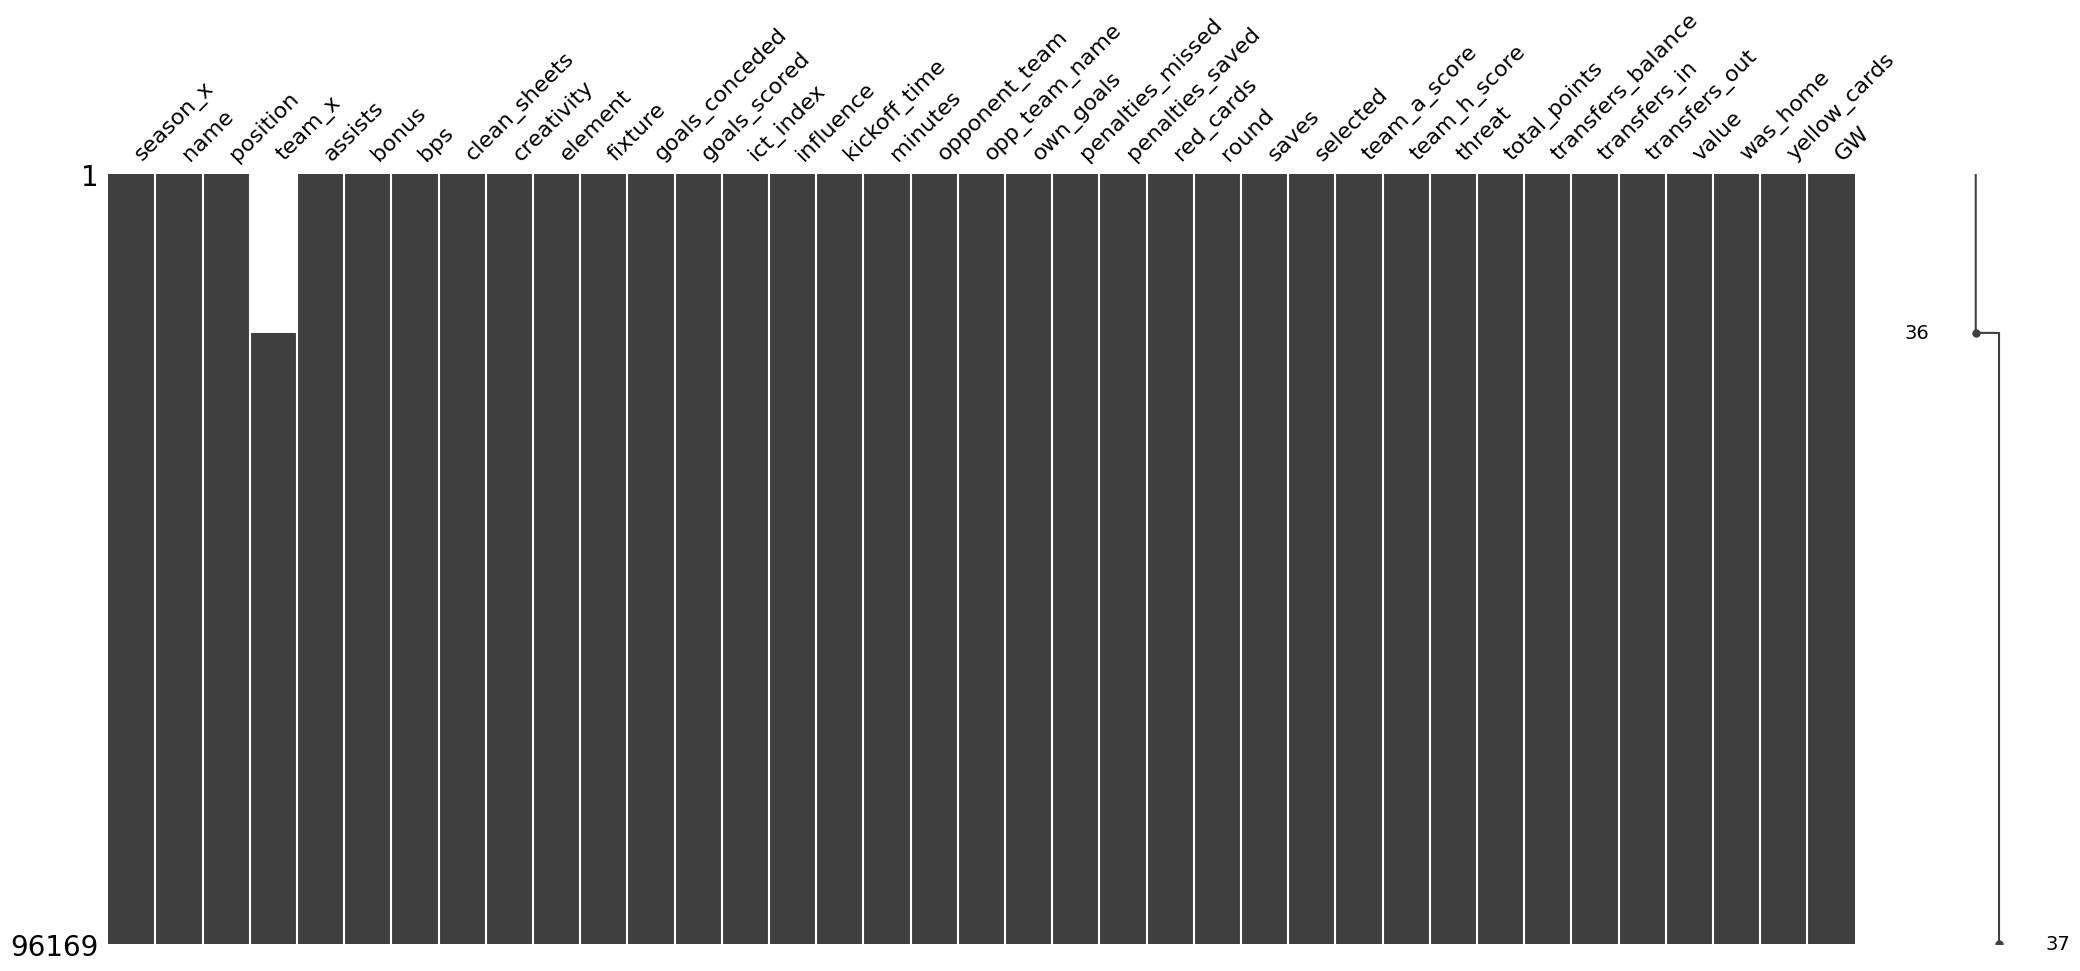

In [205]:
import missingno as msno
msno.matrix(fpl)

We think that season_x should be dropped since this information is encoded in the kickoff_time

In [206]:
fpl.groupby('season_x')['team_x'].apply(lambda x: x.isnull().sum())

season_x
2016-17     8567
2017-18    11285
2020-21        0
2021-22        0
2022-23        0
Name: team_x, dtype: int64

In [207]:
unique_players_1617 = fpl[fpl['season_x'] == '2016-17']['name'].unique()
unique_players_1718 = fpl[fpl['season_x'] == '2017-18']['name'].unique()

print("Unique players in 2016/17:", len(unique_players_1617))
print("Unique players in 2017/18:", len(unique_players_1718))

Unique players in 2016/17: 243
Unique players in 2017/18: 315


 We will proceed to fill in the missing names of the teams by the opponent name of the team that played in the same fixture

In [208]:
# Step 1 - Test, get two players who played in the same fixture for the same season
df_grouped = fpl.groupby(['season_x', 'fixture'])['opp_team_name'].unique().reset_index()
df_grouped['opp_team_name'] = df_grouped['opp_team_name'].apply(list)
df_grouped

,season_x,fixture,opp_team_name
0,2016-17,1,"[Swansea, Burnley]"
1,2016-17,2,"[West Brom, Crystal Palace]"
2,2016-17,3,"[Spurs, Everton]"
3,2016-17,4,"[Leicester, Hull]"
4,2016-17,5,"[Sunderland, Man City]"
...,...,...,...
1895,2022-23,376,"[Everton, Bournemouth]"
1896,2022-23,377,"[Spurs, Leeds]"
1897,2022-23,378,"[West Ham, Leicester]"
1898,2022-23,379,"[Man Utd, Fulham]"


In [209]:
fpl_copy = fpl.copy()

<Axes: >

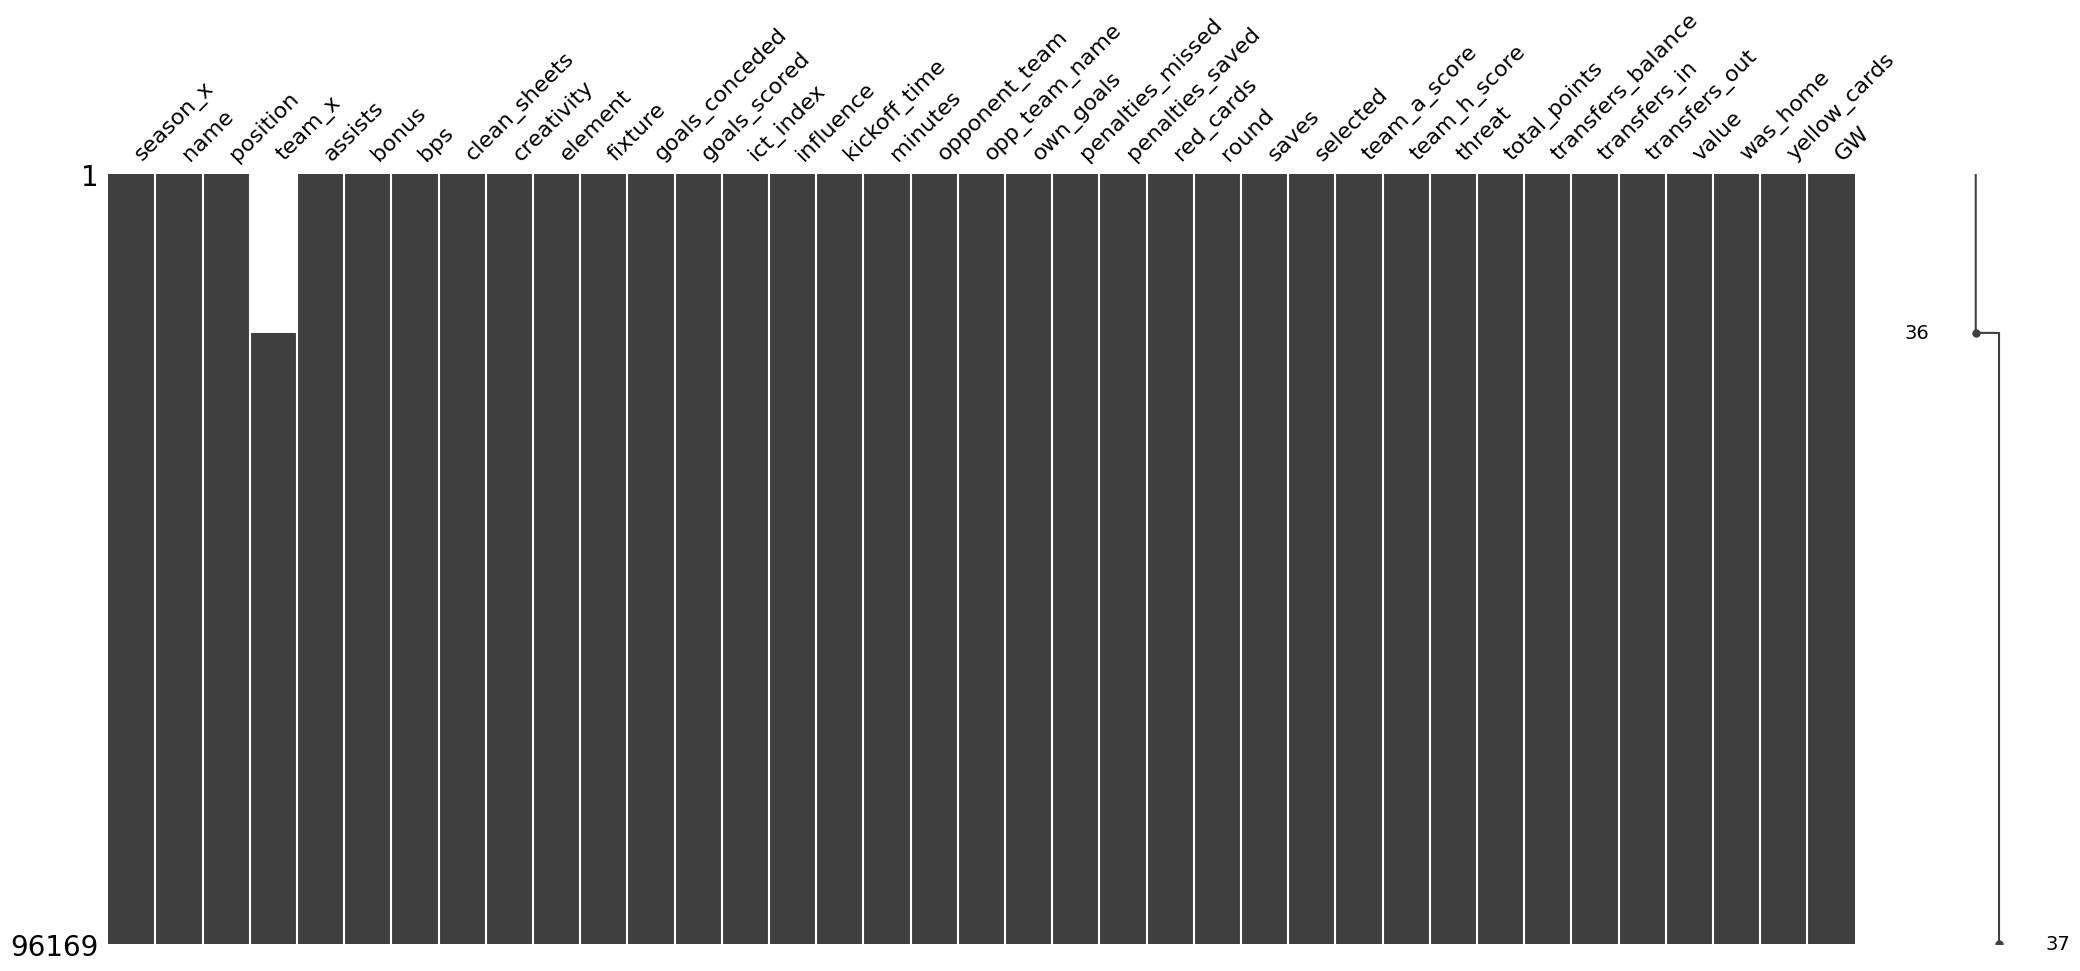

In [210]:
msno.matrix(fpl_copy)

In [211]:
df_grouped = fpl.groupby(['season_x', 'fixture'])['opp_team_name'].unique().reset_index()
df_grouped['opp_team_name'] = df_grouped['opp_team_name'].apply(list)
def fill_team_x_vectorized(df, df_grouped):
    
    # Create a mapping from (season_x, fixture) to list of teams
    fixture_team_map = {(row['season_x'], row['fixture']): row['opp_team_name'] for _, row in df_grouped.iterrows()}
    
    # Only fill where team_x is null
    mask = df['team_x'].isnull()
    # Get all teams for each row's fixture
    all_teams = df.loc[mask].apply(lambda row: fixture_team_map.get((row['season_x'], row['fixture']), []), axis=1)
    # Find the other team
    other_team = [
        [t for t in teams if t != row['opp_team_name']][0] if len(teams) == 2 else np.nan
        for teams, (_, row) in zip(all_teams, df.loc[mask].iterrows())
    ]
    # Fill missing team_x
    df.loc[mask, 'team_x'] = other_team
    return df

fpl_copy = fill_team_x_vectorized(fpl_copy, df_grouped)

In [212]:
fpl_copy.isnull().sum()

season_x             0
name                 0
position             0
team_x               0
assists              0
bonus                0
bps                  0
clean_sheets         0
creativity           0
element              0
fixture              0
goals_conceded       0
goals_scored         0
ict_index            0
influence            0
kickoff_time         0
minutes              0
opponent_team        0
opp_team_name        0
own_goals            0
penalties_missed     0
penalties_saved      0
red_cards            0
round                0
saves                0
selected             0
team_a_score         0
team_h_score         0
threat               0
total_points         0
transfers_balance    0
transfers_in         0
transfers_out        0
value                0
was_home             0
yellow_cards         0
GW                   0
dtype: int64

In [213]:
fpl_copy.to_csv('filled_teams_seasons_2.csv', index=False)

## Data Transformation

### Checking for Data Consistency

Checking to see how many players play more than one match in a season

In [214]:
duplicate_players = fpl[fpl.duplicated(subset=['name', 'GW'], keep=False)]
duplicates_summary = duplicate_players.groupby(['name', 'GW', 'season_x']).size().reset_index(name='count')
duplicates_summary = duplicates_summary[duplicates_summary['count'] > 1]
duplicates_summary.describe()

,GW,count
count,5860.000000,5860.000000
mean,29.094198,2.009215
std,5.884796,0.102455
min,1.000000,2.000000
25%,25.000000,2.000000
50%,29.000000,2.000000
75%,35.000000,2.000000
max,38.000000,4.000000


In [215]:
duplicates_summary.head(20)

,name,GW,season_x,count
39,Aaron Connolly,22,2021-22,2
43,Aaron Connolly,25,2021-22,2
51,Aaron Connolly,29,2021-22,2
57,Aaron Connolly,33,2021-22,2
157,Aaron Cresswell,19,2020-21,2
167,Aaron Cresswell,21,2021-22,2
170,Aaron Cresswell,22,2017-18,2
207,Aaron Cresswell,29,2022-23,2
231,Aaron Cresswell,34,2022-23,2
243,Aaron Cresswell,37,2017-18,2


We noticed that goalkeeper position is written in two different formats "GK" and "GKP" so we are standarizing the way it is addressed

In [216]:
fpl_copy.position.unique()

array(['DEF', 'MID', 'GK', 'FWD', 'GKP'], dtype=object)

In [217]:
fpl_copy["position"] = fpl_copy["position"].replace({"GKP": "GK"})

In [218]:
position_encoded = pd.get_dummies(fpl_copy['position'], prefix='pos', dtype = int)
fpl_copy = pd.concat([fpl_copy, position_encoded], axis=1)
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,False,0,1,1,0,0,0
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,True,0,1,0,0,0,1
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,True,0,1,0,0,0,1
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,False,0,1,0,0,0,1
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,True,1,1,0,0,0,1


In [219]:
fpl_copy["position"].unique()

array(['DEF', 'MID', 'GK', 'FWD'], dtype=object)

In [220]:
fpl_copy["was_home"] = fpl_copy["was_home"].astype(int)

In [221]:
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,0,0,1,1,0,0,0
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,1,0,1,0,0,0,1
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,1,0,1,0,0,0,1
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,0,0,1,0,0,0,1
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,1,1,1,0,0,0,1


##########################################

In [222]:
sorted_teams = sorted(fpl_copy["team_x"].unique())
sorted_teams

['Arsenal',
 'Aston Villa',
 'Bournemouth',
 'Brentford',
 'Brighton',
 'Burnley',
 'Chelsea',
 'Crystal Palace',
 'Everton',
 'Fulham',
 'Huddersfield',
 'Hull',
 'Leeds',
 'Leicester',
 'Liverpool',
 'Man City',
 'Man Utd',
 'Middlesbrough',
 'Newcastle',
 'Norwich',
 "Nott'm Forest",
 'Sheffield Utd',
 'Southampton',
 'Spurs',
 'Stoke',
 'Sunderland',
 'Swansea',
 'Watford',
 'West Brom',
 'West Ham',
 'Wolves']

In [223]:
team_x_unique = set(fpl_copy['team_x'].unique())
opp_team_name_unique = set(fpl_copy['opp_team_name'].unique())

difference_team_x = team_x_unique - opp_team_name_unique
difference_opp_team_name = opp_team_name_unique - team_x_unique

print("Values in team_x not in opp_team_name:", difference_team_x)
print("Values in opp_team_name not in team_x:", difference_opp_team_name)

Values in team_x not in opp_team_name: set()
Values in opp_team_name not in team_x: set()


#### Checking for consistency in the name column

Insights: 

last name may differ from the same player like Adama Traoré',
 'Adama Traoré Diarra', 

 and first name 

 'Aboubakar Kamara',
 'Abu Kamara',

If we can't a common column, then our best bet is a fuzzy approach however luckily we found on the github some extra data sets that have a column called code that is consistent across seasons

Proposed Fuzzy Technique: 

- Across different Seasons, check if two or more players >15 common characters (or shorter name is present in longer version of same name) (Or a better technique)
- Check if those players play for the same team
- Check if the player has the same position

we notice here that the element(id) of a player is the same throughout the same season but differs in different seasons

We need to find a way to connect same players throughout different seasons

In [224]:
sorted_players = sorted(fpl_copy["name"].unique())
sorted_players

['Aaron Connolly',
 'Aaron Cresswell',
 'Aaron Hickey',
 'Aaron Lennon',
 'Aaron Mooy',
 'Aaron Ramsdale',
 'Aaron Ramsey',
 'Aaron Wan-Bissaka',
 'Abdoulaye Doucouré',
 'Aboubakar Kamara',
 'Abu Kamara',
 'Adam Armstrong',
 'Adam Forshaw',
 'Adam Idah',
 'Adam Lallana',
 'Adam Masina',
 'Adam Smith',
 'Adam Webster',
 'Adama Traoré',
 'Adama Traoré Diarra',
 'Adedapo Awokoya-Mebude',
 'Ademipo Odubeko',
 'Ademola Lookman',
 'Adrian Blake',
 'Adrien Silva',
 'Adrián Bernabé',
 'Adrián San Miguel del Castillo',
 'Ahmed El Mohamady',
 'Ahmed El-Sayed Hegazy',
 'Ainsley Maitland-Niles',
 'Ajibola Alese',
 'Albert Sambi Lokonga',
 'Albian Ajeti',
 'Alejandro Garnacho',
 'Alejandro Garnacho Ferreyra',
 'Aleksandar Mitrović',
 'Alex Iwobi',
 'Alex Kirk',
 'Alex Kral',
 'Alex McCarthy',
 'Alex Mighten',
 'Alex Nicolao Telles',
 'Alex Oxlade-Chamberlain',
 'Alex Robertson',
 'Alex Smithies',
 'Alex Telles',
 'Alexander Isak',
 'Alexandre Jankewitz',
 'Alexandre Lacazette',
 'Alexandre Moreno L

In [225]:
fpl_copy[fpl_copy['name'].str.contains('Adama Traoré', case=False, na=False)]['team_x'].unique()

array(['Middlesbrough', 'Wolves'], dtype=object)

### Grouping by First Name

In [226]:
from collections import defaultdict

# Group by first name
first_name_groups = defaultdict(list)
for name in sorted_players:
    first = name.split()[0]
    first_name_groups[first].append(name)
# Only keep groups with more than one player
first_name_groups = {k: v for k, v in first_name_groups.items() if len(v) > 1}

first_name_groups

{'Aaron': ['Aaron Connolly',
  'Aaron Cresswell',
  'Aaron Hickey',
  'Aaron Lennon',
  'Aaron Mooy',
  'Aaron Ramsdale',
  'Aaron Ramsey',
  'Aaron Wan-Bissaka'],
 'Adam': ['Adam Armstrong',
  'Adam Forshaw',
  'Adam Idah',
  'Adam Lallana',
  'Adam Masina',
  'Adam Smith',
  'Adam Webster'],
 'Adama': ['Adama Traoré', 'Adama Traoré Diarra'],
 'Adrián': ['Adrián Bernabé', 'Adrián San Miguel del Castillo'],
 'Ahmed': ['Ahmed El Mohamady', 'Ahmed El-Sayed Hegazy'],
 'Alejandro': ['Alejandro Garnacho', 'Alejandro Garnacho Ferreyra'],
 'Alex': ['Alex Iwobi',
  'Alex Kirk',
  'Alex Kral',
  'Alex McCarthy',
  'Alex Mighten',
  'Alex Nicolao Telles',
  'Alex Oxlade-Chamberlain',
  'Alex Robertson',
  'Alex Smithies',
  'Alex Telles'],
 'Alexandre': ['Alexandre Jankewitz',
  'Alexandre Lacazette',
  'Alexandre Moreno Lopera'],
 'Alfie': ['Alfie Devine', 'Alfie Gilchrist', 'Alfie Mawson'],
 'Allan': ['Allan Marques Loureiro',
  'Allan Saint-Maximin',
  'Allan Tchaptchet'],
 'Andreas': ['Andre

### Grouping By Last Name

In [227]:
# Group by last name
last_name_groups = defaultdict(list)
for name in sorted_players:
    last = name.split()[-1]
    last_name_groups[last].append(name)
# Only keep groups with more than one player
last_name_groups = {k: v for k, v in last_name_groups.items() if len(v) > 1}
last_name_groups

{'Cresswell': ['Aaron Cresswell', 'Charlie Cresswell'],
 'Ramsey': ['Aaron Ramsey', 'Jacob Ramsey'],
 'Doucouré': ['Abdoulaye Doucouré', 'Cheick Doucouré'],
 'Kamara': ['Aboubakar Kamara',
  'Abu Kamara',
  'Boubacar Kamara',
  'Hassane Kamara'],
 'Armstrong': ['Adam Armstrong', 'Stuart Armstrong'],
 'Smith': ['Adam Smith', 'Jackson Smith', 'Jordan Smith', 'Matthew Smith'],
 'Traoré': ['Adama Traoré', 'Bertrand Traoré', 'Boubacar Traoré'],
 'Silva': ['Adrien Silva',
  'Bernardo Mota Veiga de Carvalho e Silva',
  'Bernardo Veiga de Carvalho e Silva',
  'Diego Carlos Santos Silva',
  'Diogo Teixeira da Silva',
  'Fabio Silva',
  'Gabriel Martinelli Silva',
  'Gabriel Teodoro Martinelli Silva',
  'João Victor Gomes da Silva',
  'Lucas Rodrigues Moura da Silva',
  'Thiago Emiliano da Silva',
  'Willian Borges Da Silva',
  'Willian Borges da Silva',
  'Willian José Da Silva',
  'Xande Nascimento da Costa Silva'],
 'McCarthy': ['Alex McCarthy', 'James McCarthy'],
 'Telles': ['Alex Nicolao Te

We now use the code column from the raw data set to match the players across different seasons

The steps are as follows: 
- For Each Season --> Match the element column with the id column in the corressponding raw data and add the column "code" in a new column,

In [228]:
raw_16_17['season_x'] = '2016-17'
raw_17_18['season_x'] = '2017-18'
raw_20_21['season_x'] = '2020-21'
raw_21_22['season_x'] = '2021-22'
raw_22_23['season_x'] = '2022-23'

season_mapping = {
    '2016-17': raw_16_17,  # or whatever your season identifiers are
    '2017-18': raw_17_18,
    '2020-21': raw_20_21,
    '2021-22': raw_21_22,
    '2022-23': raw_22_23
}

# Add a season identifier to each season dataframe
for season_name, df in season_mapping.items():
    df['season_x'] = season_name

# Combine all seasons
combined_seasons = pd.concat(season_mapping.values(), ignore_index=True)

# Join based on both Element and Season
fpl_copy = fpl_copy.merge(
    combined_seasons[['id', 'code', 'season_x']], 
    left_on=['element', 'season_x'], 
    right_on=['id', 'season_x'], 
    how='left'
)
fpl_copy = fpl_copy.drop('id', axis=1)

fpl_copy.sample(10)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code
86590,2022-23,Dane Scarlett,FWD,Spurs,0,0,0,0,0.0,447,269,0,0,0.0,0.0,2023-03-11T15:00:00Z,0,16,Nott'm Forest,0,0,0,0,27,0,3462,1.0,3.0,0.0,0,-24,0,24,45,1,0,27,0,1,0,0,490145
20781,2020-21,Toby Alderweireld,DEF,Spurs,0,0,0,0,0.0,386,17,0,0,0.0,0.0,2020-09-20T11:00:00Z,0,16,Southampton,0,0,0,0,2,0,181839,5.0,2.0,0.0,0,-10421,9316,19737,55,0,0,2,1,0,0,0,55605
39454,2020-21,Nathaniel Phillips,DEF,Liverpool,0,0,0,0,0.0,589,313,0,0,0.0,0.0,2021-04-19T19:00:00Z,0,10,Leeds,0,0,0,0,32,0,254468,1.0,1.0,0.0,0,40894,48255,7361,41,0,0,32,1,0,0,0,197464
11716,2017-18,Ryan Bertrand,DEF,Southampton,0,0,0,0,0.0,307,187,0,0,0.0,0.0,2017-12-23T15:00:00Z,0,8,Huddersfield,0,0,0,0,19,0,407125,1.0,1.0,0.0,0,-33965,11143,45108,54,1,0,19,1,0,0,0,40146
70882,2022-23,Trevoh Chalobah,DEF,Chelsea,0,0,0,0,0.0,141,25,0,0,0.0,0.0,2022-08-21T13:00:00Z,0,11,Leeds,0,0,0,0,3,0,43342,0.0,3.0,0.0,0,-7683,1830,9513,49,0,0,3,1,0,0,0,180736
89599,2022-23,Kyle John,DEF,Everton,0,0,0,0,0.0,637,297,0,0,0.0,0.0,2023-04-08T11:30:00Z,0,14,Man Utd,0,0,0,0,30,0,4855,0.0,2.0,0.0,0,51,141,90,40,0,0,30,1,0,0,0,232829
2598,2016-17,Willian Borges Da Silva,MID,Chelsea,0,0,0,0,0.0,86,17,0,0,0.0,0.0,2016-08-20T14:00:00Z,0,18,Watford,0,0,0,0,2,0,350399,2.0,1.0,0.0,0,-8808,17671,26479,75,0,0,2,0,0,0,1,47431
72964,2022-23,Norberto Murara Neto,GK,Bournemouth,0,0,7,0,0.0,574,58,2,0,0.5,5.0,2022-09-03T14:00:00Z,90,16,Nott'm Forest,0,0,0,0,6,1,13185,3.0,2.0,0.0,0,2352,3404,1052,45,0,1,6,0,0,1,0,69752
95198,2022-23,Mikkel Damsgaard,MID,Brentford,0,0,4,0,0.4,580,368,0,0,1.1,8.2,2023-05-20T11:30:00Z,45,18,Spurs,0,0,0,0,37,0,7574,3.0,1.0,2.0,1,31,107,76,50,0,0,37,0,0,0,1,440089
87951,2022-23,Yegor Yarmolyuk,MID,Brentford,0,0,0,0,0.0,650,283,0,0,0.0,0.0,2023-04-01T14:00:00Z,0,5,Brighton,0,0,0,0,29,0,643,3.0,3.0,0.0,0,12,57,45,45,0,0,29,0,0,0,1,601975


In [229]:
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,0,0,1,1,0,0,0,55459
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,1,0,1,0,0,0,1,17349
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,1,0,1,0,0,0,1,41792
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,0,0,1,0,0,0,1,121599
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,1,1,1,0,0,0,1,80179


## Checking for Duplicates

In [230]:
duplicates = fpl[fpl_copy.duplicated()]

In [231]:
duplicates.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW


In [232]:
duplicates.count()

season_x             0
name                 0
position             0
team_x               0
assists              0
bonus                0
bps                  0
clean_sheets         0
creativity           0
element              0
fixture              0
goals_conceded       0
goals_scored         0
ict_index            0
influence            0
kickoff_time         0
minutes              0
opponent_team        0
opp_team_name        0
own_goals            0
penalties_missed     0
penalties_saved      0
red_cards            0
round                0
saves                0
selected             0
team_a_score         0
team_h_score         0
threat               0
total_points         0
transfers_balance    0
transfers_in         0
transfers_out        0
value                0
was_home             0
yellow_cards         0
GW                   0
dtype: int64

# Creating global codes for teams

- Since the opponent_team_code column changes for the teams from one season to another, we set a global code for each team and assiging it as a global value accross all seasons

In [233]:
unique_team_codes = pd.DataFrame(master["team_name"].unique(), columns=["team_name"])
unique_team_codes = unique_team_codes.reset_index().rename(columns={'index': 'team_global_code'})

- setting the code for the playes's team according to the team_x column

In [234]:
fpl_copy = fpl_copy.merge(
    unique_team_codes,
    how='left',
    left_on='team_x',
    right_on='team_name'
).rename(columns={'team_global_code': 'team_x_global_code'})
fpl_copy = fpl_copy.drop(columns=['team_name'])

- setting the code for opponent team according to opp_team_name column

In [235]:
fpl_copy = fpl_copy.merge(
    unique_team_codes,
    how='left',
    left_on='opp_team_name',
    right_on='team_name'
).rename(columns={'team_global_code': 'opponent_team_global_code'})
fpl_copy = fpl_copy.drop(columns=['team_name'])

In [236]:
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,0,0,1,1,0,0,0,55459,19,3
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,1,0,1,0,0,0,1,17349,5,16
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,1,0,1,0,0,0,1,41792,0,8
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,0,0,1,0,0,0,1,121599,17,12
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,1,1,1,0,0,0,1,80179,11,13


# Create upcoming total points column

- We need to create the label, which is the upcoming_total_points for each player
- We then need to make sure that the last match for any player to be set to NA
- We chose the approach to nullify the last match only so 1 game for each player, so upcoming total points carries from one season to another

In [237]:
# Sort properly first
fpl_copy = fpl_copy.sort_values(['code', 'season_x', 'GW'])

# Upcoming total points (next GW)
fpl_copy['upcoming_total_points'] = fpl_copy.groupby(['code'])['total_points'].shift(-1)

#set the last instance 
last_indices = fpl_copy.groupby('code').tail(1).index
fpl_copy.loc[last_indices, 'upcoming_total_points'] = pd.NA


- Here we check for the total numbe rof null values against the count of unique players to make sure that the last game for each player is set to NA

In [238]:
num_nulls = fpl_copy['upcoming_total_points'].isnull().sum()
num_unique_players = fpl_copy['code'].nunique()

print(num_nulls, num_unique_players)

1264 1264


# Creating Form Column 

- We create the form column by calculating the mean of the last 4 game weeks (if available)
- We allow the form to carry from one season to another

In [239]:

fpl_copy['form'] = (
    fpl_copy.groupby('code')['total_points']
      .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()) / 10
)
fpl_copy['form'].fillna(0, inplace=True)
fpl_copy.head()

C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_34132\12840432.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fpl_copy['form'].fillna(0, inplace=True)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form
7409,2016-17,Lee Grant,GK,Stoke,0,0,0,0,0.0,574,37,0,0,0.0,0.0,2016-09-10T14:00:00Z,0,17,Spurs,0,0,0,0,4,0,376,4.0,0.0,0.0,0,211,230,19,40,1,0,4,0,0,1,0,6744,13,16,0.0,0.000000
7622,2016-17,Lee Grant,GK,Stoke,0,0,0,0,0.0,574,47,0,0,0.0,0.0,2016-09-18T13:15:00Z,0,5,Crystal Palace,0,0,0,0,5,0,1807,1.0,4.0,0.0,0,607,712,105,40,0,0,5,0,0,1,0,6744,13,4,2.0,0.000000
7835,2016-17,Lee Grant,GK,Stoke,0,0,13,0,0.0,574,56,1,0,1.4,14.0,2016-09-24T14:00:00Z,90,19,West Brom,0,0,0,0,6,2,3232,1.0,1.0,0.0,2,668,878,210,40,1,0,6,0,0,1,0,6744,13,18,5.0,0.000000
8048,2016-17,Lee Grant,GK,Stoke,0,1,24,0,0.0,574,65,1,0,5.9,59.0,2016-10-02T11:00:00Z,90,11,Man Utd,0,0,0,0,7,8,8564,1.0,1.0,0.0,5,4034,4546,512,40,0,0,7,0,0,1,0,6744,13,10,6.0,0.066667
8262,2016-17,Lee Grant,GK,Stoke,0,0,23,1,0.0,574,79,0,0,0.8,8.2,2016-10-15T14:00:00Z,90,15,Sunderland,0,0,0,0,8,1,32985,0.0,2.0,0.0,6,20881,21951,1070,40,1,0,8,0,0,1,0,6744,13,14,6.0,0.175000


In [240]:
# Explicit mapping for the five seasons
season_code_map = {
    '2016-17': 1,
    '2017-18': 2,
    '2020-21': 3,
    '2021-22': 4,
    '2022-23': 5
}

# Create the code column (unknown/missing -> 0)
fpl_copy['season_x_code'] = fpl_copy['season_x'].map(season_code_map).fillna(0).astype(int)
fpl_copy.sample(10)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code
16635,2017-18,Kieran Trippier,DEF,Spurs,0,0,14,0,14.5,382,339,3,0,3.3,18.0,2018-04-14T18:45:00Z,90,11,Man City,0,0,0,0,34,0,270651,3.0,1.0,0.0,1,-570,11360,11930,52,1,0,34,1,0,0,0,77794,16,9,0.0,0.150,2
90833,2022-23,Sam Surridge,FWD,Nott'm Forest,0,0,3,0,0.1,391,318,0,0,0.0,0.0,2023-04-22T14:00:00Z,3,12,Liverpool,0,0,0,0,32,0,79311,2.0,3.0,0.0,1,-556,569,1125,46,0,0,32,0,1,0,0,217331,31,8,0.0,0.025,5
14358,2017-18,Nathaniel Chalobah,MID,Watford,0,0,0,0,0.0,112,270,0,0,0.0,0.0,2018-02-10T15:00:00Z,0,20,West Ham,0,0,0,0,27,0,38679,0.0,2.0,0.0,0,-532,730,1262,42,0,0,27,0,0,0,1,89085,17,19,0.0,0.000,2
11332,2017-18,Kasper Schmeichel,GK,Leicester,0,0,14,0,0.0,189,176,3,0,2.7,27.4,2017-12-16T12:30:00Z,90,6,Crystal Palace,0,0,0,0,18,3,241739,3.0,0.0,0.0,2,-572,4589,5161,50,1,0,18,0,0,1,0,17745,7,4,2.0,0.400,2
67915,2021-22,Luke Ayling,DEF,Leeds,0,0,0,0,0.0,185,323,0,0,0.0,0.0,2022-05-11T18:30:00Z,0,6,Chelsea,0,0,0,0,36,0,295823,3.0,0.0,0.0,0,14824,20328,5504,43,1,0,36,1,0,0,0,66588,29,3,0.0,0.275,4
68717,2021-22,Viljami Sinisalo,GK,Aston Villa,0,0,0,0,0.0,596,171,0,0,0.0,0.0,2022-05-19T19:00:00Z,0,5,Burnley,0,0,0,0,37,0,6921,1.0,1.0,0.0,0,85,247,162,40,1,0,37,0,0,1,0,248164,26,2,0.0,0.000,4
54907,2021-22,Ross Barkley,MID,Chelsea,0,0,0,0,0.0,124,181,0,0,0.0,0.0,2021-12-26T17:30:00Z,0,2,Aston Villa,0,0,0,0,19,0,8202,3.0,1.0,0.0,0,-49,177,226,52,0,0,19,0,0,0,1,88894,3,26,0.0,0.025,4
27396,2020-21,Bertrand Traoré,MID,Aston Villa,1,2,48,1,45.3,540,138,0,1,16.5,67.6,2020-12-20T19:15:00Z,90,18,West Brom,0,0,0,0,14,0,4704,3.0,0.0,52.0,13,344,677,333,59,0,0,14,0,0,0,1,110504,26,18,7.0,0.300,3
84397,2022-23,Benoît Badiashile,DEF,Chelsea,0,0,20,0,10.8,689,234,1,0,2.7,14.0,2023-02-18T15:00:00Z,90,17,Southampton,0,0,0,0,24,0,121648,1.0,0.0,2.0,2,28976,37887,8911,50,1,0,24,1,0,0,0,242880,3,12,0.0,0.525,5
23239,2020-21,Josh Benson,MID,Burnley,0,0,0,0,0.0,535,60,0,0,0.0,0.0,2020-10-31T15:00:00Z,0,5,Chelsea,0,0,0,0,7,0,1346,3.0,0.0,0.0,0,25,141,116,45,1,0,7,0,0,0,1,217401,2,3,0.0,0.000,3


# Calculating Team Strength Column

In [241]:
fpl_copy = fpl_copy.sort_values(['season_x', 'GW', 'team_x_global_code'])


team_week_avg = (
    fpl_copy.groupby(['season_x', 'GW', 'team_x_global_code'])['total_points']
    .mean()
    .reset_index()
    .rename(columns={'total_points': 'team_avg_points'})
)

In [242]:
team_week_avg['team_strength'] = (
    team_week_avg.groupby(['season_x', 'team_x_global_code'])['team_avg_points']
    .transform(lambda x: x.shift(1).expanding().mean())
)

fpl_copy = fpl_copy.merge(
    team_week_avg[['season_x', 'GW', 'team_x_global_code', 'team_strength']],
    on=['season_x', 'GW', 'team_x_global_code'],
    how='left'
)

In [243]:
fpl_copy.sample(10)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code,team_strength
16949,2017-18,Francisco Femenía Far,DEF,Watford,0,0,0,0,0.0,407,290,0,0,0.0,0.0,2018-03-03T15:00:00Z,0,19,West Brom,0,0,0,0,29,0,72582,0.0,1.0,0.0,0,2180,3076,896,43,1,0,29,1,0,0,0,54484,17,18,1.0,0.025,2,1.922403
23203,2020-21,Cheikhou Kouyaté,MID,Crystal Palace,0,0,17,0,0.9,133,68,2,0,1.5,13.8,2020-10-30T20:00:00Z,90,20,Wolves,0,0,0,0,7,0,50274,0.0,2.0,0.0,2,-2703,3711,6414,50,0,0,7,0,0,0,1,55037,4,25,2.0,0.375,3,1.411983
3787,2016-17,Jack Stephens,DEF,Southampton,0,0,0,0,0.0,504,178,0,0,0.0,0.0,2016-12-28T19:45:00Z,0,17,Spurs,0,0,0,0,18,0,14812,4.0,1.0,0.0,0,-191,83,274,40,1,0,18,1,0,0,0,88900,12,16,0.0,0.000,1,1.755190
69911,2022-23,Anthony Elanga,MID,Man Utd,0,0,2,0,0.1,344,9,0,0,0.0,0.2,2022-08-07T13:00:00Z,1,5,Brighton,0,0,0,0,1,0,77705,2.0,1.0,0.0,1,0,0,0,50,1,0,1,0,0,0,1,449434,10,20,1.0,0.275,5,NaN
66293,2021-22,Harry Tyrer,GK,Everton,0,0,0,0,0.0,616,342,0,0,0.0,0.0,2022-05-01T13:00:00Z,0,6,Chelsea,0,0,0,0,35,0,4424,0.0,1.0,0.0,0,-28,38,66,40,1,0,35,0,0,1,0,447325,5,3,0.0,0.000,4,0.938589
54849,2021-22,Japhet Tanganga,DEF,Spurs,0,0,26,1,3.8,371,188,0,0,4.9,19.4,2021-12-26T15:00:00Z,90,7,Crystal Palace,0,0,0,0,19,0,99598,0.0,3.0,26.0,6,-884,2783,3667,42,1,0,19,1,0,0,0,199584,16,4,0.0,0.225,4,1.483402
34178,2020-21,João Filipe Iria Santos Moutinho,MID,Wolves,0,0,9,0,4.7,454,236,1,0,0.9,2.8,2021-02-14T12:00:00Z,90,16,Southampton,0,0,0,0,24,0,69301,2.0,1.0,1.0,2,-343,869,1212,52,0,0,24,0,0,0,1,19624,25,12,3.0,0.375,3,1.207085
89419,2022-23,Saïd Benrahma,MID,West Ham,0,0,3,0,11.1,464,293,0,0,2.0,1.4,2023-04-08T14:00:00Z,30,9,Fulham,0,0,0,0,30,0,123241,1.0,0.0,7.0,1,-3349,5197,8546,55,0,0,30,0,0,0,1,172841,19,24,7.0,0.350,5,1.288389
1937,2016-17,Connor Wickham,FWD,Crystal Palace,0,0,0,0,0.0,122,91,0,0,0.0,0.0,2016-10-29T16:30:00Z,0,9,Liverpool,0,0,0,0,10,0,15809,4.0,2.0,0.0,0,-589,232,821,56,1,0,10,0,1,0,0,59125,4,8,5.0,0.050,1,2.148148
59102,2021-22,Thomas Partey,MID,Arsenal,0,0,19,0,37.8,15,191,1,0,5.5,11.2,2022-02-24T19:45:00Z,90,20,Wolves,0,0,0,0,26,0,21966,1.0,2.0,6.0,2,1023,1641,618,50,1,0,26,0,0,0,1,167199,0,25,2.0,0.225,4,1.332924


In [244]:
opp_week_avg = (
    fpl_copy.groupby(['season_x', 'GW', 'opponent_team_global_code'])['total_points']
    .mean()
    .reset_index()
    .rename(columns={
        'opponent_team_global_code': 'team_x_global_code',
        'total_points': 'team_avg_points'
    })
)

opp_week_avg['opponent_strength'] = (
    opp_week_avg.groupby(['season_x', 'team_x_global_code'])['team_avg_points']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Merge back (but this time match on opponent_team_global_code)
fpl_copy = fpl_copy.merge(
    opp_week_avg[['season_x', 'GW', 'team_x_global_code', 'opponent_strength']],
    left_on=['season_x', 'GW', 'opponent_team_global_code'],
    right_on=['season_x', 'GW', 'team_x_global_code'],
    how='left'
).drop(columns=['team_x_global_code_y']).rename(columns={'team_x_global_code_x': 'team_x_global_code'})


In [245]:
# Create strength_difference as team_strength minus opponent_strength
fpl_copy['strength_difference'] = fpl_copy['team_strength'] - fpl_copy['opponent_strength']

# Quick checks
print("Missing team_strength:", fpl_copy['team_strength'].isna().sum())
print("Missing opponent_strength:", fpl_copy['opponent_strength'].isna().sum())
print("Missing strength_difference:", fpl_copy['strength_difference'].isna().sum())

# Inspect a few rows to confirm
fpl_copy[['season_x', 'GW', 'team_x', 'opp_team_name', 'team_strength', 'opponent_strength', 'strength_difference']].sample(10)

Missing team_strength: 2127
Missing opponent_strength: 2121
Missing strength_difference: 2231


,season_x,GW,team_x,opp_team_name,team_strength,opponent_strength,strength_difference
70217,2022-23,1,Nott'm Forest,Newcastle,NaN,NaN,NaN
17188,2017-18,30,Man Utd,Liverpool,2.254083,1.520206,0.733878
14249,2017-18,20,West Ham,Bournemouth,1.289525,2.190088,-0.900563
11139,2017-18,10,Crystal Palace,West Ham,0.988562,2.260413,-1.271851
40891,2020-21,34,West Ham,Burnley,1.516830,1.528680,-0.011850
21042,2020-21,3,Man Utd,Brighton,0.687500,1.334988,-0.647488
12704,2017-18,15,Southampton,Bournemouth,1.638393,2.062737,-0.424344
68326,2021-22,37,Everton,Brentford,0.961686,1.339317,-0.377631
78610,2022-23,16,Newcastle,Chelsea,1.784716,1.244076,0.540640
66889,2021-22,36,Arsenal,Leeds,1.216919,1.552561,-0.335642


In [246]:
fpl_copy.sample(10)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code,team_strength,opponent_strength,strength_difference
74755,2022-23,Joe Willock,MID,Newcastle,0,0,8,0,3.0,373,98,1,0,4.3,3.0,2022-10-08T14:00:00Z,90,4,Brentford,0,0,0,0,10,0,83819,1.0,5.0,37.0,2,30502,36171,5669,49,1,0,10,0,0,0,1,200089,22,30,1.0,0.425,5,1.631317,1.390077,0.241240
12403,2017-18,Cédric Soares,DEF,Southampton,0,0,12,0,0.2,310,139,1,0,1.1,10.8,2017-11-29T20:00:00Z,86,11,Man City,0,0,0,0,14,0,351282,1.0,2.0,0.0,2,-35659,1510,37169,49,0,0,14,1,0,0,0,58822,12,9,0.0,0.175,2,1.629808,0.842063,0.787745
2764,2016-17,Harry Arter,MID,Bournemouth,0,0,12,0,3.3,37,131,3,0,0.6,1.8,2016-12-04T13:30:00Z,90,9,Liverpool,0,0,0,0,14,0,12249,3.0,4.0,1.0,2,-290,409,699,50,1,0,14,0,0,0,1,48615,1,8,1.0,0.150,1,1.981218,1.662199,0.319018
68776,2021-22,Ezri Konsa Ngoyo,DEF,Aston Villa,0,0,0,0,0.0,45,171,0,0,0.0,0.0,2022-05-19T19:00:00Z,0,5,Burnley,0,0,0,0,37,0,88401,1.0,1.0,0.0,0,3481,5245,1764,49,1,0,37,1,0,0,0,199798,26,2,0.0,0.100,4,1.147125,1.489064,-0.341939
40367,2020-21,Steven Alzate,MID,Brighton,0,0,0,0,0.0,79,326,0,0,0.0,0.0,2021-04-24T19:00:00Z,0,15,Sheffield Utd,0,0,0,0,33,0,46070,0.0,1.0,0.0,0,-1075,196,1271,42,0,0,33,0,0,0,1,235382,20,28,0.0,0.000,3,1.143498,1.805774,-0.662275
5063,2016-17,Andros Townsend,MID,Crystal Palace,0,0,12,0,21.6,120,232,0,0,5.3,14.4,2017-02-04T15:00:00Z,45,15,Sunderland,0,0,0,0,24,0,82876,4.0,0.0,17.0,1,-1008,589,1597,59,1,0,24,0,0,0,1,60252,4,14,2.0,0.175,1,2.198598,2.263012,-0.064415
60782,2021-22,Owen Dodgson,DEF,Burnley,0,0,0,0,0.0,565,272,0,0,0.0,0.0,2022-03-05T15:00:00Z,0,6,Chelsea,0,0,0,0,28,0,8724,4.0,0.0,0.0,0,19,206,187,39,1,0,28,1,0,0,0,461567,2,3,0.0,0.000,4,1.200027,0.903206,0.296821
30489,2020-21,Matheus Pereira,MID,West Brom,0,2,29,0,3.5,481,175,2,1,5.6,37.2,2021-01-19T18:00:00Z,90,19,West Ham,0,0,0,0,19,0,50842,1.0,2.0,15.0,9,275,1629,1354,56,0,0,19,0,0,0,1,210407,18,19,2.0,0.550,3,0.988172,1.265948,-0.277776
26307,2020-21,Axel Tuanzebe,DEF,Man Utd,0,0,0,0,0.0,307,115,0,0,0.0,0.0,2020-12-12T17:30:00Z,0,12,Man City,0,0,0,0,12,0,7937,0.0,0.0,0.0,0,-474,326,800,43,1,0,12,1,0,0,0,180804,10,9,0.0,0.025,3,1.189633,1.175867,0.013766
27383,2020-21,Jonas Lössl,GK,Everton,0,0,0,0,0.0,151,133,0,0,0.0,0.0,2020-12-19T17:30:00Z,0,1,Arsenal,0,0,0,0,14,0,9399,1.0,2.0,0.0,0,50,235,185,43,1,0,14,0,0,1,0,57513,5,0,0.0,0.000,3,1.546557,1.564693,-0.018136


## Checking For Corelation and Redundancy

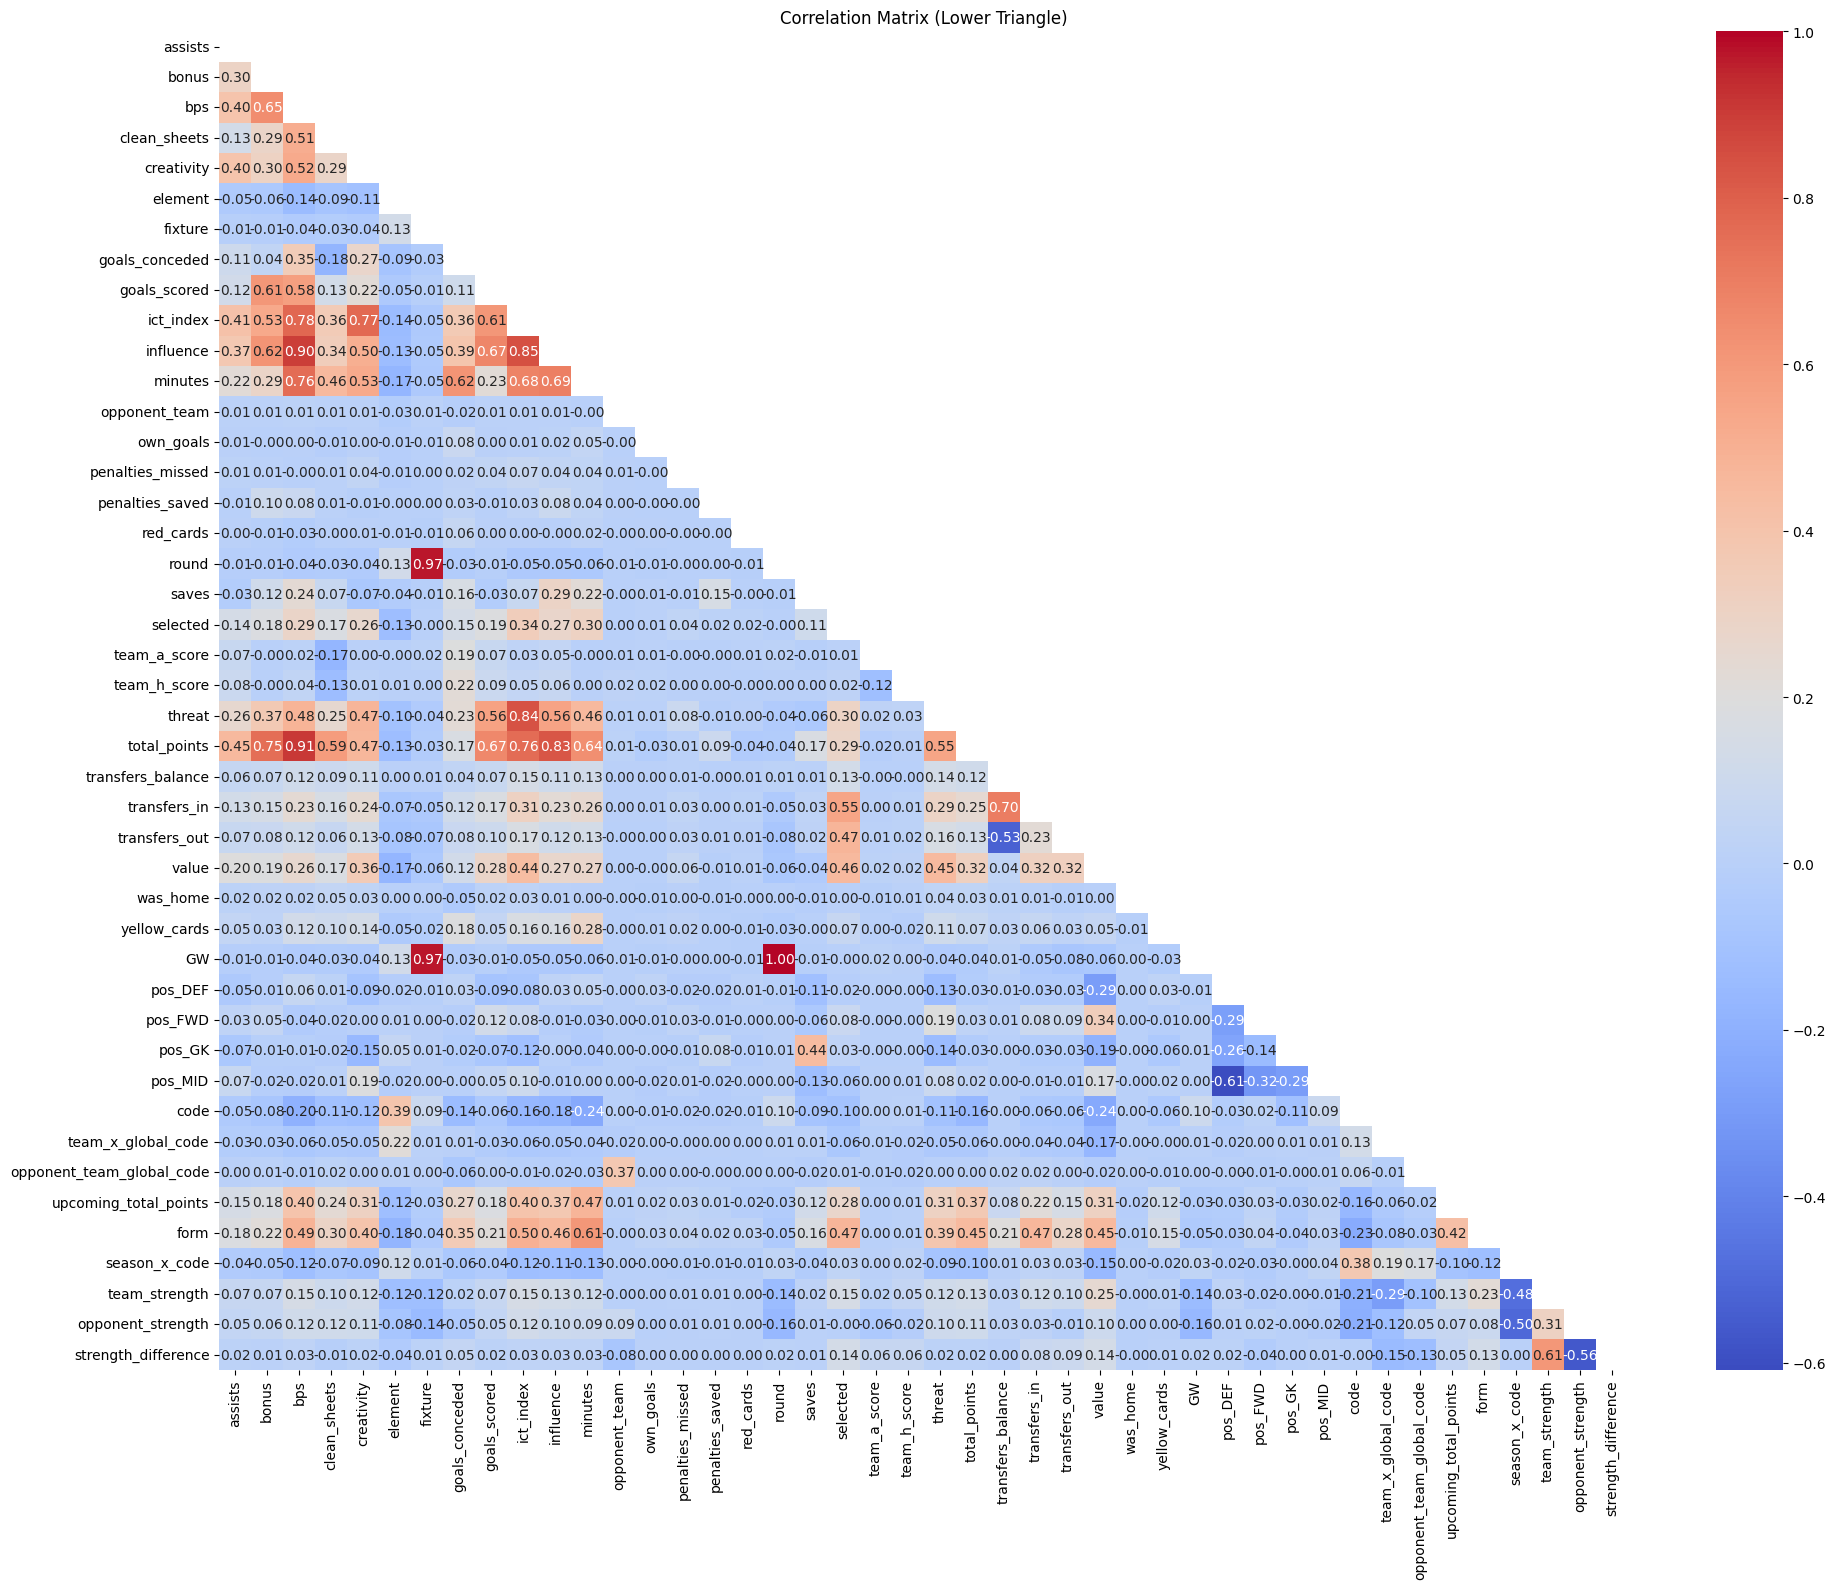

In [247]:
corr = fpl_copy.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f",
    cmap='coolwarm', 
    annot_kws={"size": 10}
)
plt.title('Correlation Matrix (Lower Triangle)')
plt.tight_layout()
plt.show()

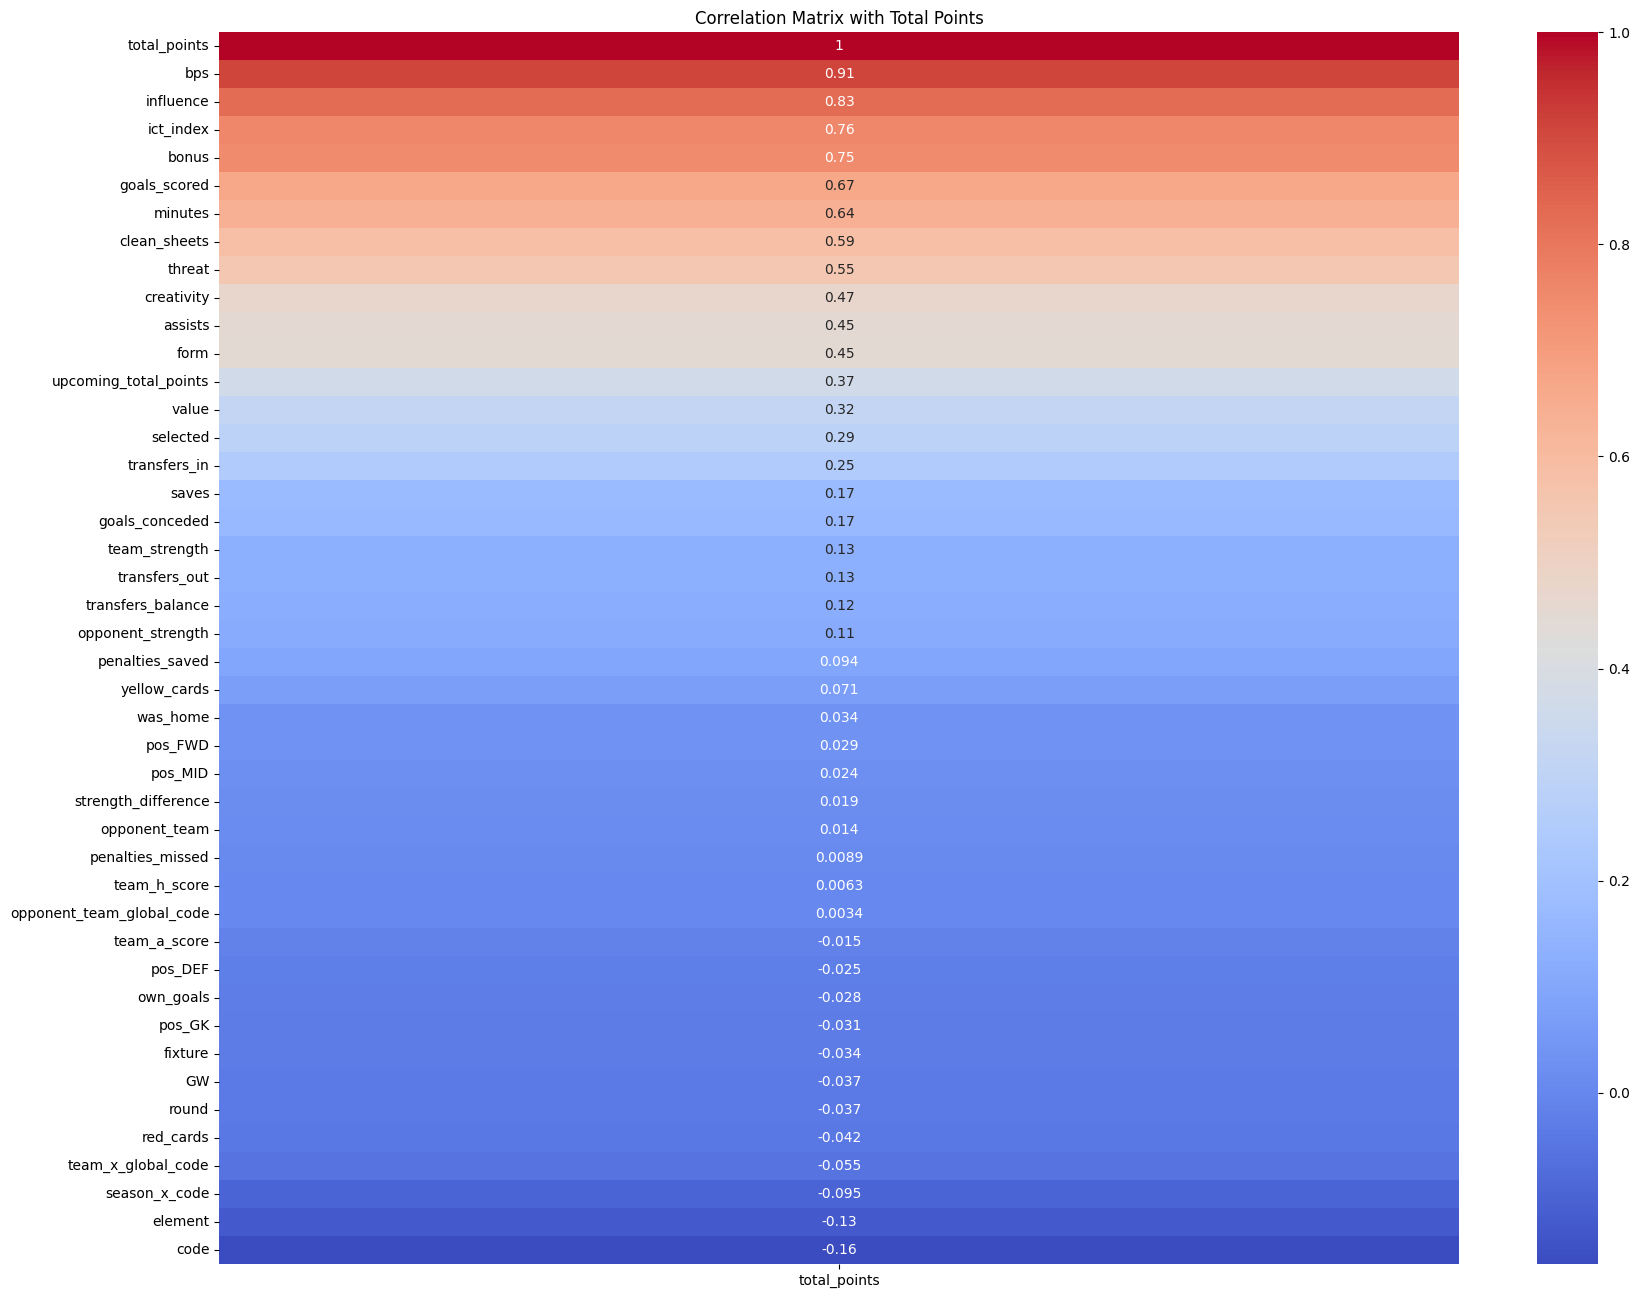

In [248]:
corr = fpl_copy.corr(numeric_only=True)
plt.figure(figsize=(20, 16))
sns.heatmap(corr[['total_points']].sort_values(by='total_points', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix with Total Points')
plt.show()

In [249]:
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code,team_strength,opponent_strength,strength_difference
0,2016-17,Theo Walcott,MID,Arsenal,0,0,21,0,20.0,13,8,4,1,10.5,46.6,2016-08-14T15:00:00Z,90,9,Liverpool,0,1,0,0,1,0,48930,4.0,3.0,38.0,5,0,0,0,75,1,0,1,0,0,0,1,20467,0,8,3.0,0.0,1,NaN,NaN,NaN
1,2016-17,Mesut Özil,MID,Arsenal,0,0,0,0,0.0,14,8,0,0,0.0,0.0,2016-08-14T15:00:00Z,0,9,Liverpool,0,0,0,0,1,0,179727,4.0,3.0,0.0,0,0,0,0,95,1,0,1,0,0,0,1,37605,0,8,1.0,0.0,1,NaN,NaN,NaN
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,1,0,1,0,0,0,1,41792,0,8,0.0,0.0,1,NaN,NaN,NaN
3,2016-17,Kieran Gibbs,DEF,Arsenal,0,0,0,0,0.0,7,8,0,0,0.0,0.0,2016-08-14T15:00:00Z,0,9,Liverpool,0,0,0,0,1,0,22607,4.0,3.0,0.0,0,0,0,0,50,1,0,1,1,0,0,0,42427,0,8,0.0,0.0,1,NaN,NaN,NaN
4,2016-17,Olivier Giroud,FWD,Arsenal,0,0,0,0,0.0,25,8,0,0,0.0,0.0,2016-08-14T15:00:00Z,0,9,Liverpool,0,0,0,0,1,0,50997,4.0,3.0,0.0,0,0,0,0,90,1,0,1,0,1,0,0,44346,0,8,1.0,0.0,1,NaN,NaN,NaN


Across the seasons, which player positions (e.g., goalkeeper, defender, midfielder, etc.) score the largest sum of total points on average?


In [250]:
ans=fpl_copy.groupby(['season_x','position'])['total_points'].mean().unstack()
for row in ans.itertuples():
    largest=-1
    pos =''
    if row.GK > largest:
        largest=row.GK
        pos='GK'
    if row.DEF > largest:
        largest=row.DEF
        pos='DEF'
    if row.MID > largest:
        largest=row.MID
        pos='MID'
    if row.FWD > largest:
        largest=row.FWD
        pos='FWD'
    print(f"{row.Index}: | Highest: {largest:.2f} | Position: {pos}")

    

2016-17: | Highest: 2.27 | Position: FWD
2017-18: | Highest: 2.11 | Position: FWD
2020-21: | Highest: 1.46 | Position: FWD
2021-22: | Highest: 1.32 | Position: MID
2022-23: | Highest: 1.42 | Position: FWD


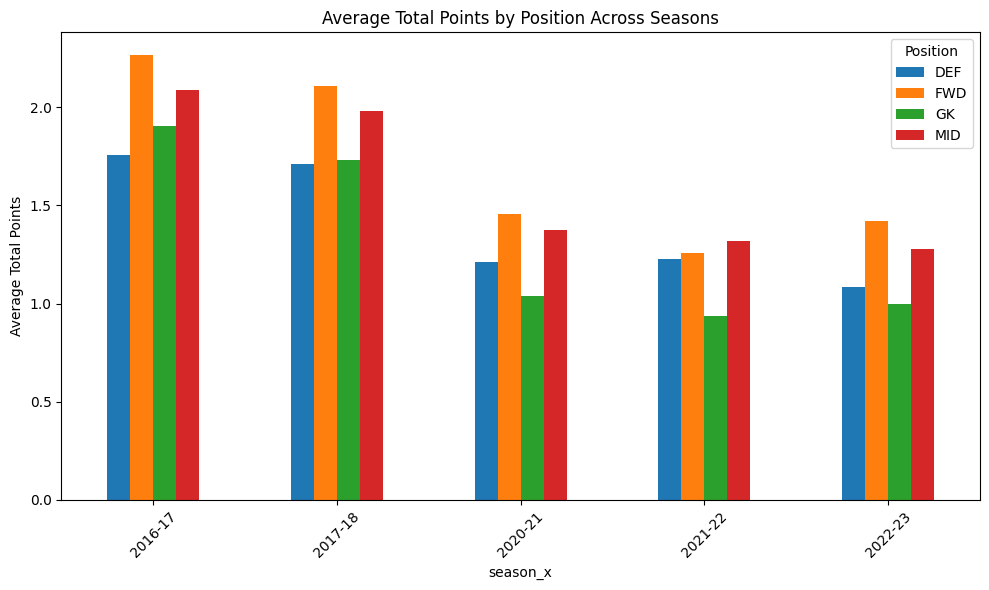

In [251]:
ans.plot(kind='bar', figsize=(10,6))
plt.ylabel('Average Total Points')
plt.title('Average Total Points by Position Across Seasons')
plt.xticks(rotation=45)
plt.legend(title='Position')
plt.tight_layout()
plt.show()

In [252]:
fpl_copy.columns

Index(['season_x', 'name', 'position', 'team_x', 'assists', 'bonus', 'bps',
       'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded',
       'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes',
       'opponent_team', 'opp_team_name', 'own_goals', 'penalties_missed',
       'penalties_saved', 'red_cards', 'round', 'saves', 'selected',
       'team_a_score', 'team_h_score', 'threat', 'total_points',
       'transfers_balance', 'transfers_in', 'transfers_out', 'value',
       'was_home', 'yellow_cards', 'GW', 'pos_DEF', 'pos_FWD', 'pos_GK',
       'pos_MID', 'code', 'team_x_global_code', 'opponent_team_global_code',
       'upcoming_total_points', 'form', 'season_x_code', 'team_strength',
       'opponent_strength', 'strength_difference'],
      dtype='object')

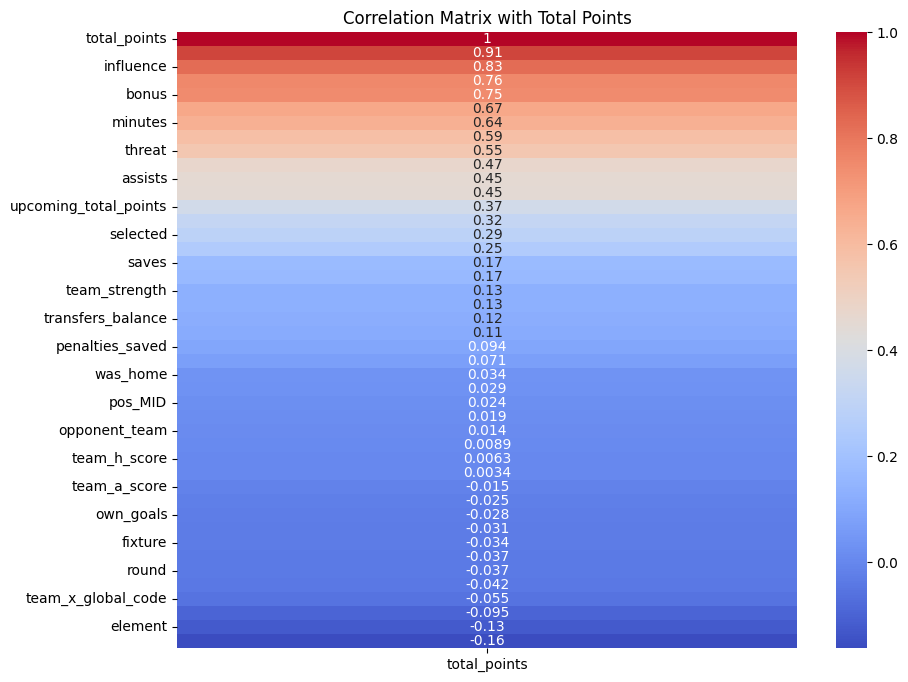

In [253]:
corr = fpl_copy.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr[['total_points']].sort_values(by='total_points', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix with Total Points')
plt.show()

# Prediction Model

In [254]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
fpl_model = fpl_copy.dropna(subset=['upcoming_total_points']).copy()


features = [
    'minutes', 'goals_scored', 'assists', 'clean_sheets',
    'influence', 'creativity', 'threat', 'ict_index', 'form' , 'bps', 
    # , 'value',
    # 'was_home', 'team_x_global_code', 'opponent_team_global_code', 'form', "team_strength", "opponent_strength"
]

X = fpl_model[features]
y = fpl_model['upcoming_total_points']


In [256]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [257]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential, Input
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import r2_score


In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
    ])

In [259]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [260]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='MAE'),
        keras.metrics.MeanSquaredError(name='MSE'),
        keras.metrics.RootMeanSquaredError(name='RMSE')
    ]
)

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
    learning_rate=0.001,
)

Epoch 1/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - MAE: 1.2382 - MSE: 4.8438 - RMSE: 2.2009 - loss: 4.8438 - val_MAE: 1.2227 - val_MSE: 4.8470 - val_RMSE: 2.2016 - val_loss: 4.8470
Epoch 2/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2287 - MSE: 4.7793 - RMSE: 2.1862 - loss: 4.7793 - val_MAE: 1.2691 - val_MSE: 4.8280 - val_RMSE: 2.1973 - val_loss: 4.8280
Epoch 3/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2268 - MSE: 4.7590 - RMSE: 2.1815 - loss: 4.7590 - val_MAE: 1.2493 - val_MSE: 4.8277 - val_RMSE: 2.1972 - val_loss: 4.8277
Epoch 4/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2268 - MSE: 4.7556 - RMSE: 2.1807 - loss: 4.7556 - val_MAE: 1.1870 - val_MSE: 4.8641 - val_RMSE: 2.2055 - val_loss: 4.8641
Epoch 5/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2241 - MSE: 4.7521 - RMSE: 2.1799 - loss: 4.7521 - val_MAE: 1.2301 - val_MSE: 4.8626 - val_RMSE: 2.2051 - val_loss: 4.8626
Epoch 6/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2249 - 

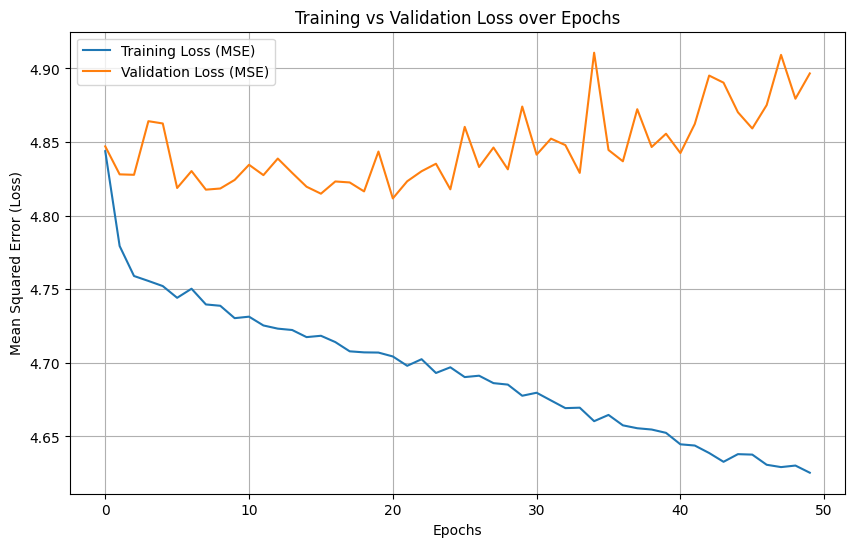

In [269]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training vs Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()

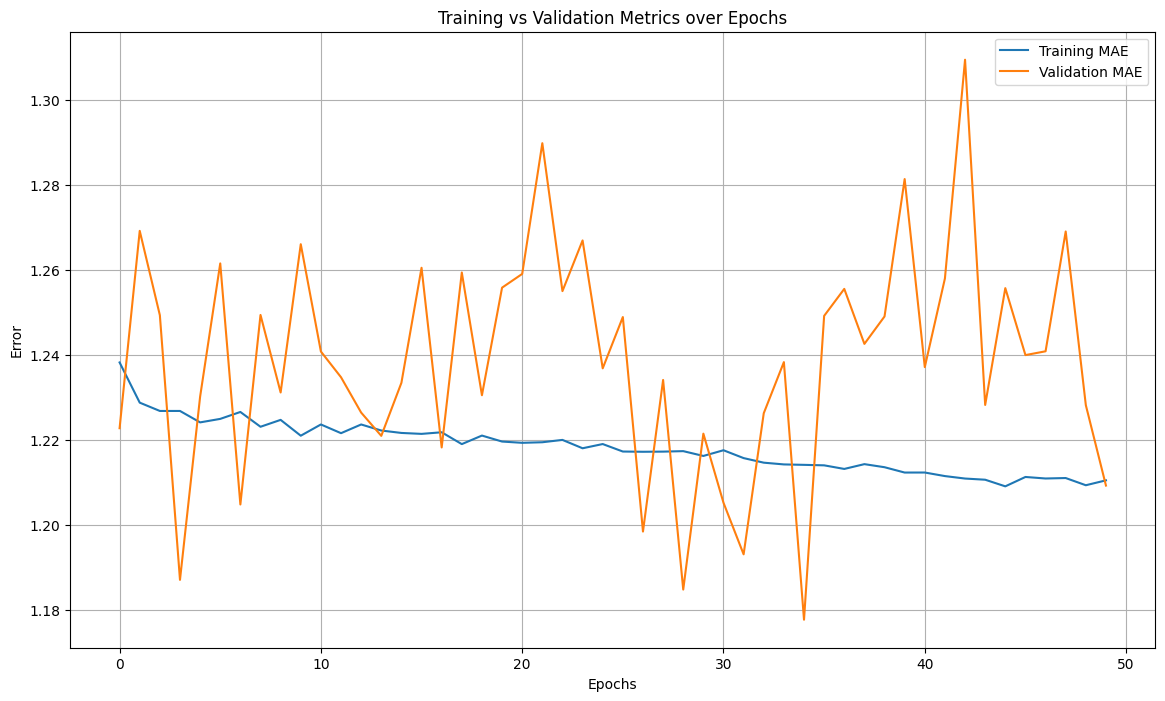

In [272]:
metrics = ['MAE']

plt.figure(figsize=(14,8))

for metric in ['MAE']:
    plt.plot(history.history[metric], label=f'Training {metric}')
    plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')

plt.title('Training vs Validation Metrics over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

In [262]:
results = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"MAE: {results[1]:.3f}")
print(f"MSE: {results[2]:.3f}")
print(f"RMSE: {results[3]:.3f}")

y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")

MAE: 1.214
MSE: 4.807
RMSE: 2.192
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step
R²: 0.258


In [263]:
features_2 = [
    'total_points', 'minutes', 'goals_scored', 'assists', 'clean_sheets',
    'influence', 'creativity', 'threat', 'ict_index', 'form' , 'bps', 'strength_difference', 'pos_GK',
    'pos_DEF', 'pos_MID', 'pos_FWD'
    # , 'value',
    # 'was_home', 'team_x_global_code', 'opponent_team_global_code', 'form', "team_strength", "opponent_strength"
]
X = fpl_model[features_2]
y = fpl_model['upcoming_total_points']

In [264]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [265]:
model_2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
    ])

In [267]:
model_2.compile(
    optimizer='adam',
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='MAE'),
        keras.metrics.MeanSquaredError(name='MSE'),
        keras.metrics.RootMeanSquaredError(name='RMSE')
    ]
)

In [268]:
history_2 = model_2.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - MAE: 1.6620 - MSE: 6.5648 - RMSE: 2.5622 - loss: 6.5648 - val_MAE: 1.6992 - val_MSE: 6.5672 - val_RMSE: 2.5626 - val_loss: 6.5672
Epoch 2/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.6914 - MSE: 6.4638 - RMSE: 2.5424 - loss: 6.4638 - val_MAE: 1.6708 - val_MSE: 6.5741 - val_RMSE: 2.5640 - val_loss: 6.5741
Epoch 3/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.6895 - MSE: 6.4645 - RMSE: 2.5425 - loss: 6.4645 - val_MAE: 1.6858 - val_MSE: 6.5694 - val_RMSE: 2.5631 - val_loss: 6.5694
Epoch 4/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.6883 - MSE: 6.4630 - RMSE: 2.5422 - loss: 6.4630 - val_MAE: 1.7427 - val_MSE: 6.5727 - val_RMSE: 2.5637 - val_loss: 6.5727
Epoch 5/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.6911 - MSE: 6.4637 - RMSE: 2.5424 - loss: 6.4637 - val_MAE: 1.6937 - val_MSE: 6.5678 - val_RMSE: 2.5628 - val_loss: 6.5678
Epoch 6/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.6892 - 

In [273]:
results = model_2.evaluate(X_test_scaled, y_test, verbose=0)
print(f"MAE: {results[1]:.3f}")
print(f"MSE: {results[2]:.3f}")
print(f"RMSE: {results[3]:.3f}")

y_pred = model_2.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")

MAE: 1.699
MSE: 6.475
RMSE: 2.545
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step
R²: -0.000
